# Inteligencia Colectiva: Enjambres de Partículas (PSO) y Colonias de Hormigas (ACO)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/06_inteligencia_enjambres_pso.ipynb)

## Objetivos


- Contrastar los paradigmas de Computación Evolutiva (competición/muerte) con la Inteligencia de Enjambres (cooperación/aprendizaje).
- Comprender e implementar **Particle Swarm Optimization (PSO)** para espacios continuos, analizando su modelo de velocidad y posición.
- Comprender e implementar **Ant Colony Optimization (ACO)** para espacios discretos (grafos).
- Resolver el Problema del Viajante de Comercio (TSP) utilizando ACO y comparar su rendimiento y lógica subyacente contra el Algoritmo Genético.



## Prerrequisitos


- Haber completado: [Estrategias Evolutivas (ES) y Evolución Diferencial (DE)](05_estrategias_evolutivas_y_de.ipynb).
- Familiaridad con el Problema del Viajante de Comercio (TSP) visto en [Optimización Combinatoria: Espacios Discretos y Permutaciones
](04_optimizacion_combinatoria.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
from itertools import repeat
warnings.filterwarnings('ignore')

try:
    import deap
except ImportError:
    !pip install deap
from deap import base, creator, tools

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 27.3 MB/s eta 0:00:00


## Introducción Teórica: Evolución vs. Cooperación



Hasta ahora, todos los algoritmos que vimos (GA, ES, DE) se basan en los supuestos de la evolución darwiniana: **supervivencia del más apto**. En estos algoritmos, los individuos compiten, los peores son eliminados (mueren) y los mejores combinan sus genes para crear nueva descendencia.

La **Inteligencia de Enjambres (Swarm Intelligence)** propone un paradigma radicalmente distinto, inspirado en el comportamiento de bandadas de aves, bancos de peces, colonias de insectos (etc. etc.):
1. **Nadie muere:** La población (el enjambre) es constante.
2. **No hay cruce genético:** Los individuos no se mezclan para crear hijos.
3. **Cooperación y Memoria:** Los individuos se mueven por el espacio de búsqueda ajustando su trayectoria en base a su propia experiencia (memoria individual) y a los descubrimientos de sus vecinos (memoria colectiva).

Exploramos los dos algoritmos rey de este paradigma: **PSO** (para espacios continuos) y **ACO** (para espacios discretos/grafos).



## Parte I: Particle Swarm Optimization (PSO)



Propuesto por Kennedy y Eberhart en 1995, PSO simula una bandada de pájaros buscando comida. Cada "pájaro" (partícula) tiene una **posición** $x$ y una **velocidad** $v$.

En cada iteración, la partícula actualiza su velocidad basándose en tres fuerzas:
1. **Inercia ($w$):** La tendencia a seguir moviéndose en la dirección actual.
2. **Fuerza Cognitiva ($c_1$):** La nostalgia por el mejor lugar donde *esa partícula en particular* ha estado (`pbest`).
3. **Fuerza Social ($c_2$):** La presión de grupo para volar hacia el mejor lugar que *todo el enjambre* ha encontrado (`gbest`).

La ecuación de actualización de velocidad es:

$$ v_{t+1} = w \cdot v_t + c_1 \cdot r_1 \cdot (pbest - x_t) + c_2 \cdot r_2 \cdot (gbest - x_t) $$

*(Donde $r_1$ y $r_2$ son números aleatorios entre 0 y 1 para darle estocasticidad al vuelo).*

Y la posición se actualiza simplemente sumando la velocidad:

$$ x_{t+1} = x_t + v_{t+1} $$

### 1. Implementación de PSO en DEAP



DEAP no tiene un algoritmo `eaPSO` prefabricado en su módulo `algorithms` (*pero si ejemplos, conviene mirarlos siempre*), pero su arquitectura `creator` es flexible y podemos construir las partículas (esto sería "lo nuevo") y el bucle evolutivo de forma elegante (ya lo hicimos varias veces), siguiendo las directrices oficiales del framework. Así que va otro ejemplo de implementación con DEAP:


In [2]:
import operator
import math

# Limpiamos el entorno
for cls in ['FitnessMin', 'Particle']:
    if hasattr(creator, cls): delattr(creator, cls)

# 1. Definimos el Fitness (Minimización)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# 2. Definimos la Partícula
# Hereda de 'list' (para la posición), pero le añadimos atributos extra:
# speed (velocidad), smin/smax (límites de velocidad) y best (memoria de su mejor posición).
creator.create("Particle", list, fitness=creator.FitnessMin, speed=list,
               smin=None, smax=None, best=None)

def generar_particula(size, pmin, pmax, smin, smax):
    """Genera una partícula con posición y velocidad aleatorias."""
    part = creator.Particle(random.uniform(pmin, pmax) for _ in range(size))
    part.speed = [random.uniform(smin, smax) for _ in range(size)]
    part.smin = smin
    part.smax = smax
    return part

def actualizar_particula(part, best, w, c1, c2):
    """Aplica la ecuación de velocidad y posición de PSO usando el módulo operator."""
    # Generamos los vectores aleatorios r1 y r2
    r1 = (random.uniform(0, 1) for _ in range(len(part)))
    r2 = (random.uniform(0, 1) for _ in range(len(part)))

    # Calculamos las componentes cognitiva y social
    v_u1 = map(operator.mul, map(operator.mul, repeat(c1), r1), map(operator.sub, part.best, part))
    v_u2 = map(operator.mul, map(operator.mul, repeat(c2), r2), map(operator.sub, best, part))

    # Sumamos inercia + cognitivo + social
    part.speed = list(map(operator.add, map(operator.mul, repeat(w), part.speed), map(operator.add, v_u1, v_u2)))

    # Aplicamos límites de velocidad (Clipping)
    for i, speed in enumerate(part.speed):
        if abs(speed) < part.smin:
            part.speed[i] = math.copysign(part.smin, speed)
        elif abs(speed) > part.smax:
            part.speed[i] = math.copysign(part.smax, speed)

    # Actualizamos posición
    part[:] = list(map(operator.add, part, part.speed))

# 3. Configuramos el Toolbox
from itertools import repeat

tb_pso = base.Toolbox()
tb_pso.register("particle", generar_particula, size=2, pmin=-5.12, pmax=5.12, smin=-1.0, smax=1.0)
tb_pso.register("population", tools.initRepeat, list, tb_pso.particle)
tb_pso.register("update", actualizar_particula, w=0.7, c1=1.5, c2=1.5)

# Usamos la función de Rastrigin en 2D para poder visualizarla
def rastrigin_2d(ind):
    x, y = ind[0], ind[1]
    return (20 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y)),)

tb_pso.register("evaluate", rastrigin_2d)

### 2. El Bucle Evolutivo y Visualización de Trayectorias


Para entender realmente cómo funciona PSO, vamos a "ver a la bandada volar". Ejecutar el algoritmo y guardamos la posición de todas las partículas en cada generación.


In [3]:
def correr_pso_deap(N=30, G=50):
    pop = tb_pso.population(n=N)
    best = None
    historia_posiciones = []

    for g in range(G):
        # 1. Evaluación y actualización de memorias (pbest y gbest)
        for part in pop:
            part.fitness.values = tb_pso.evaluate(part)

            # Actualizamos pbest
            if not part.best or part.best.fitness < part.fitness:
                part.best = creator.Particle(part)
                part.best.fitness.values = part.fitness.values

            # Actualizamos gbest
            if not best or best.fitness < part.fitness:
                best = creator.Particle(part)
                best.fitness.values = part.fitness.values

        # Guardamos las posiciones para la visualización
        historia_posiciones.append([list(p) for p in pop])

        # 2. Actualización de velocidad y posición
        for part in pop:
            tb_pso.update(part, best)

    return historia_posiciones, best

# Ejecutamos el enjambre
hist_pso, mejor_pso = correr_pso_deap()
print(f"Mejor posición encontrada: x={mejor_pso[0]:.4f}, y={mejor_pso[1]:.4f}")
print(f"Fitness: {mejor_pso.fitness.values[0]:.4f}")

Mejor posición encontrada: x=0.0006, y=0.0003
Fitness: 0.0001


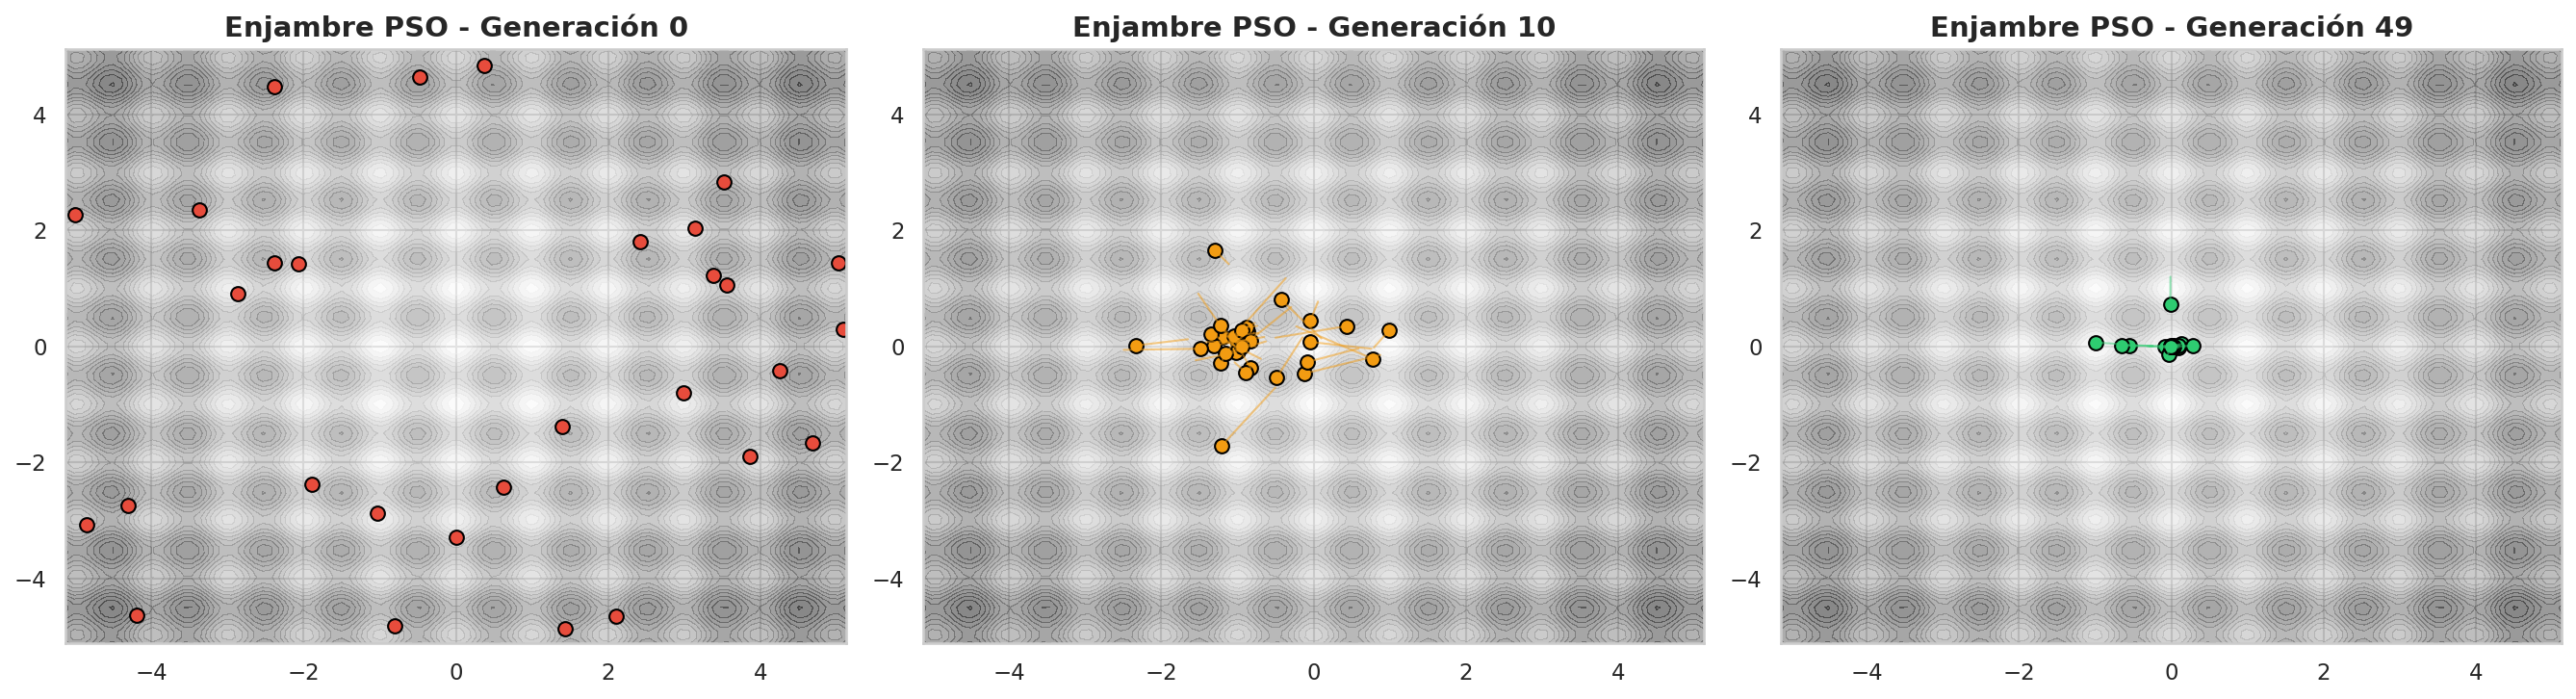

In [4]:
# --- Visualización de Trayectorias ---
x_r = np.linspace(-5.12, 5.12, 100); y_r = np.linspace(-5.12, 5.12, 100)
X_r, Y_r = np.meshgrid(x_r, y_r)
Z_r = 20 + (X_r**2 - 10*np.cos(2*np.pi*X_r)) + (Y_r**2 - 10*np.cos(2*np.pi*Y_r))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
generaciones_plot = [0, 10, 49]
colores = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, gen, color in zip(axes, generaciones_plot, colores):
    ax.contourf(X_r, Y_r, Z_r, levels=20, cmap='gray_r', alpha=0.5)
    pob_actual = np.array(hist_pso[gen])

    # Dibujamos las partículas
    ax.scatter(pob_actual[:, 0], pob_actual[:, 1], c=color, edgecolor='black', s=50)

    # Dibujamos "estelas" (trayectorias desde la generación anterior)
    if gen > 0:
        pob_anterior = np.array(hist_pso[gen-1])
        for i in range(len(pob_actual)):
            ax.plot([pob_anterior[i, 0], pob_actual[i, 0]],
                    [pob_anterior[i, 1], pob_actual[i, 1]],
                    color=color, alpha=0.5, lw=1)

    ax.set_title(f"Enjambre PSO - Generación {gen}")
    ax.set_xlim(-5.12, 5.12); ax.set_ylim(-5.12, 5.12)

plt.tight_layout()
plt.show()

Observar la Generación 0 (dispersión total). En la Generación 10, las partículas ya están volando hacia los valles más profundos (notar las estelas que indican la dirección de la velocidad). En la Generación 49, el enjambre casi ha colapsado en el óptimo global.


> **Peligro de PSO:** Si la fuerza social ($c_2$) es muy alta, todas las partículas volarán ciegamente hacia el líder actual (`gbest`). El enjambre colapsará en un solo punto perdiendo toda su "energía cinética" y estancándose en un óptimo local. PSO es famoso por su **convergencia ultrarrápida**, pero es extremadamente propenso a la convergencia prematura si no se calibra bien la inercia ($w$).

### 3. La Trampa de la Fuerza Social

Afirmamos que si la fuerza social ($c_2$) es muy alta, el enjambre colapsa. Como ingenieros, no deberíamos confiar en afirmaciones sin datos. Vamos a demostrarlo empíricamente utilizando nuestra implementación en DEAP.

Para que el efecto sea evidente, aumentamos la dificultad del problema pasando de Rastrigin 2D a **Rastrigin 10D**. Creamos una función auxiliar que nos permita inyectar distintos valores de $w, c_1, c_2$ en el `toolbox` de DEAP y comparamos las curvas de convergencia.

Ejecutando experimentos PSO en Rastrigin 10D...


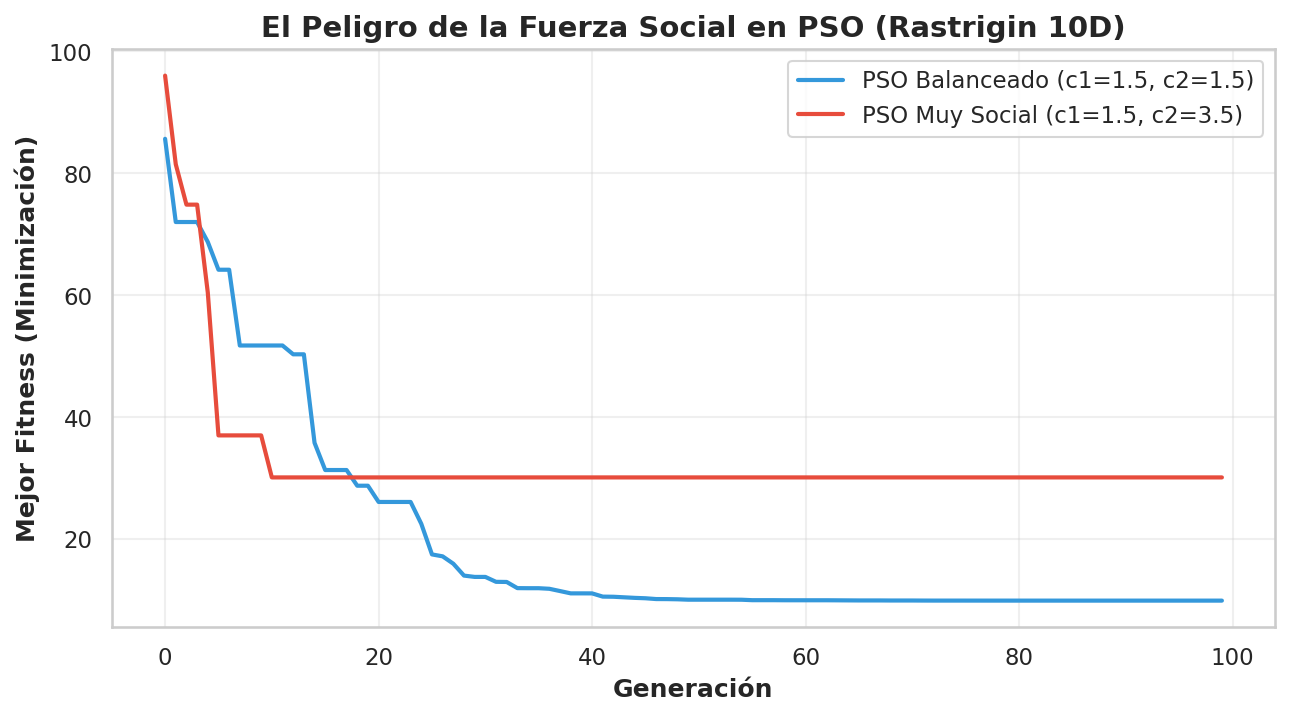

In [5]:
# Función Rastrigin para N dimensiones
def rastrigin_10d(ind):
    x = np.array(ind)
    A, D = 10, len(x)
    return (A * D + np.sum(x**2 - A * np.cos(2 * np.pi * x)),)

def experimentar_pso_deap(w, c1, c2, N=50, G=100):
    """Ejecuta PSO en DEAP con parámetros específicos y retorna la historia del mejor fitness."""
    tb_exp = base.Toolbox()
    tb_exp.register("particle", generar_particula, size=10, pmin=-5.12, pmax=5.12, smin=-1.0, smax=1.0)
    tb_exp.register("population", tools.initRepeat, list, tb_exp.particle)
    tb_exp.register("update", actualizar_particula, w=w, c1=c1, c2=c2)
    tb_exp.register("evaluate", rastrigin_10d)

    pop = tb_exp.population(n=N)
    best = None
    hist_fit = []

    for g in range(G):
        for part in pop:
            part.fitness.values = tb_exp.evaluate(part)
            if not part.best or part.best.fitness < part.fitness:
                part.best = creator.Particle(part)
                part.best.fitness.values = part.fitness.values
            if not best or best.fitness < part.fitness:
                best = creator.Particle(part)
                best.fitness.values = part.fitness.values

        hist_fit.append(best.fitness.values[0])

        for part in pop:
            tb_exp.update(part, best)

    return hist_fit

# Experimento: Balanceado vs. Exceso de Presión Social
print("Ejecutando experimentos PSO en Rastrigin 10D...")
hist_balanceado = experimentar_pso_deap(w=0.7, c1=1.5, c2=1.5)
hist_social = experimentar_pso_deap(w=0.7, c1=1.5, c2=3.5) # Exceso de presión social

plt.figure(figsize=(10, 5))
plt.plot(hist_balanceado, label='PSO Balanceado (c1=1.5, c2=1.5)', color='#3498db', lw=2)
plt.plot(hist_social, label='PSO Muy Social (c1=1.5, c2=3.5)', color='#e74c3c', lw=2)
plt.title("El Peligro de la Fuerza Social en PSO (Rastrigin 10D)")
plt.xlabel("Generación")
plt.ylabel("Mejor Fitness (Minimización)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Análisis del Diagnóstico:**  
Observar la curva roja. Cuando la fuerza social ($c_2$) es muy alta, todas las partículas vuelan ciegamente hacia el líder actual (`gbest`). El enjambre colapsa en un solo punto en menos de 20 generaciones, perdiendo toda su "energía cinética" y estancándose en un óptimo local (fitness $\approx 30$). PSO es famoso por su **convergencia ultrarrápida**, pero es extremadamente propenso a la convergencia prematura si no se calibra bien la inercia ($w$) y el balance cognitivo/social.

## Parte II: Ant Colony Optimization (ACO)



PSO es excelente para espacios continuos, pero ¿qué pasa con los espacios discretos y los grafos? Aquí entran las hormigas.

El concepto clave de ACO es la **Estigmergia**: la comunicación indirecta a través de la modificación del entorno. Las hormigas son casi ciegas, pero cuando encuentran comida, dejan un rastro de **feromonas** al volver al nido. Las siguientes hormigas tienden a seguir los rastros con más feromonas. Los caminos más cortos se recorren más rápido, por lo que acumulan feromonas más rápido, creando un ciclo de retroalimentación positiva.



### 1. Revisitando el Problema del Viajante (TSP)



En el notebook [Optimización Combinatoria: Espacios Discretos y Permutaciones
](04_optimizacion_combinatoria.ipynb), resolvimos el TSP usando un Algoritmo Genético con un cruce especial (OX Crossover). Vamos a recrear **exactamente la misma instancia sintética de 30 ciudades** para ver cómo la resuelven las hormigas.



In [6]:
N_CIUDADES = 30

# Generamos coordenadas (x, y) para las ciudades (Misma semilla para reproducibilidad)
np.random.seed(42)
ciudades = np.random.rand(N_CIUDADES, 2) * 100

# Calculamos la matriz de distancias euclidianas
from scipy.spatial import distance_matrix
matriz_distancias = distance_matrix(ciudades, ciudades)

def evaluar_ruta(individuo):
    """Calcula la distancia total de la ruta, incluyendo el regreso al inicio."""
    distancia_total = 0
    for i in range(N_CIUDADES):
        ciudad_actual = individuo[i]
        ciudad_siguiente = individuo[(i + 1) % N_CIUDADES]
        distancia_total += matriz_distancias[ciudad_actual][ciudad_siguiente]
    return distancia_total

### 2. La Matemática de la Hormiga



Para construir una ruta, una hormiga parada en la ciudad $i$ decide ir a la ciudad $j$ basándose en una probabilidad $P_{ij}$:

$$ P_{ij} = \frac{(\tau_{ij})^\alpha \cdot (\eta_{ij})^\beta}{\sum (\tau_{ik})^\alpha \cdot (\eta_{ik})^\beta} $$

*   $\tau_{ij}$ (Feromona): "Lo que la colonia aprendió". La cantidad de feromona en la arista $i \to j$.
*   $\eta_{ij}$ (Visibilidad): "Lo que ve la hormiga". Una heurística miope, típicamente el inverso de la distancia ($1 / d_{ij}$).
*   $\alpha$ y $\beta$: Pesos que controlan la importancia de la feromona vs. la visibilidad.

Al final de la generación, las feromonas se **evaporan** (para olvidar malas rutas) y las hormigas depositan nueva feromona inversamente proporcional a la longitud de su ruta ($L$):

$$ \tau_{ij} = (1 - \rho) \cdot \tau_{ij} + \sum \frac{Q}{L} $$



### 3. Implementación de ACO desde cero



> **Decisión de Software: ¿Por qué no usamos DEAP aquí?**  
> DEAP está diseñado bajo el paradigma de que *la información reside en el individuo* (sus genes) y evoluciona mediante cruce y mutación. En ACO, la hormiga es "tonta"; no tiene genes ni se cruza con otras hormigas. La inteligencia reside en el **entorno compartido** (la matriz de feromonas). Forzar a DEAP a manejar un estado global masivo que se actualiza de forma centralizada va en contra de su diseño modular. Como ingenieros, debemos saber cuándo un framework deja de ser la herramienta adecuada y es mejor volver a la eficiencia de NumPy puro.



In [7]:
def correr_aco_tsp(N_hormigas=30, G=100, alpha=1.0, beta=2.0, rho=0.1, Q=100):
    # 1. Inicialización
    # Matriz de feromonas inicial (pequeña constante)
    feromonas = np.ones((N_CIUDADES, N_CIUDADES)) * 0.1
    # Matriz de visibilidad (1 / distancia). Sumamos 1e-10 para evitar div/0
    visibilidad = 1.0 / (matriz_distancias + 1e-10)
    np.fill_diagonal(visibilidad, 0) # No podemos ir de una ciudad a sí misma

    mejor_ruta_global = None
    mejor_distancia_global = float('inf')
    historial_distancias = []

    for gen in range(G):
        rutas = []
        distancias = []

        # 2. Construcción de rutas por cada hormiga
        for h in range(N_hormigas):
            ruta = [random.randint(0, N_CIUDADES - 1)] # Ciudad inicial aleatoria
            ciudades_no_visitadas = set(range(N_CIUDADES)) - {ruta[0]}

            while ciudades_no_visitadas:
                ciudad_actual = ruta[-1]

                # Calculamos probabilidades para las ciudades restantes
                candidatas = list(ciudades_no_visitadas)
                fero = feromonas[ciudad_actual, candidatas] ** alpha
                visi = visibilidad[ciudad_actual, candidatas] ** beta

                probabilidades = fero * visi
                probabilidades /= probabilidades.sum() # Normalizamos a 1

                # Elegimos la siguiente ciudad basada en las probabilidades
                siguiente_ciudad = np.random.choice(candidatas, p=probabilidades)
                ruta.append(siguiente_ciudad)
                ciudades_no_visitadas.remove(siguiente_ciudad)

            rutas.append(ruta)
            dist = evaluar_ruta(ruta)
            distancias.append(dist)

            # Actualizamos el mejor global
            if dist < mejor_distancia_global:
                mejor_distancia_global = dist
                mejor_ruta_global = ruta.copy()

        historial_distancias.append(mejor_distancia_global)

        # 3. Evaporación de feromonas
        feromonas *= (1 - rho)

        # 4. Depósito de feromonas (Solo la mejor hormiga de la iteración deposita - Estrategia Elitista)
        mejor_idx = np.argmin(distancias)
        mejor_ruta_gen = rutas[mejor_idx]
        mejor_dist_gen = distancias[mejor_idx]

        aporte = Q / mejor_dist_gen
        for i in range(N_CIUDADES):
            c_actual = mejor_ruta_gen[i]
            c_siguiente = mejor_ruta_gen[(i + 1) % N_CIUDADES]
            # El grafo es simétrico
            feromonas[c_actual, c_siguiente] += aporte
            feromonas[c_siguiente, c_actual] += aporte

    return mejor_ruta_global, mejor_distancia_global, historial_distancias

# Ejecutamos ACO
print("Ejecutando Colonia de Hormigas...")
ruta_aco, dist_aco, hist_aco = correr_aco_tsp(N_hormigas=30, G=150)
print(f"ACO Terminado. Mejor distancia: {dist_aco:.2f}")

Ejecutando Colonia de Hormigas...
ACO Terminado. Mejor distancia: 451.77


## Visualización y Discusión de Ingeniería



Vamos a visualizar la ruta encontrada por las hormigas y compararla con el rendimiento que obtuvimos con el Algoritmo Genético en el notebook [Optimización Combinatoria: Espacios Discretos y Permutaciones
](04_optimizacion_combinatoria.ipynb) (que rondaba una distancia de 460).



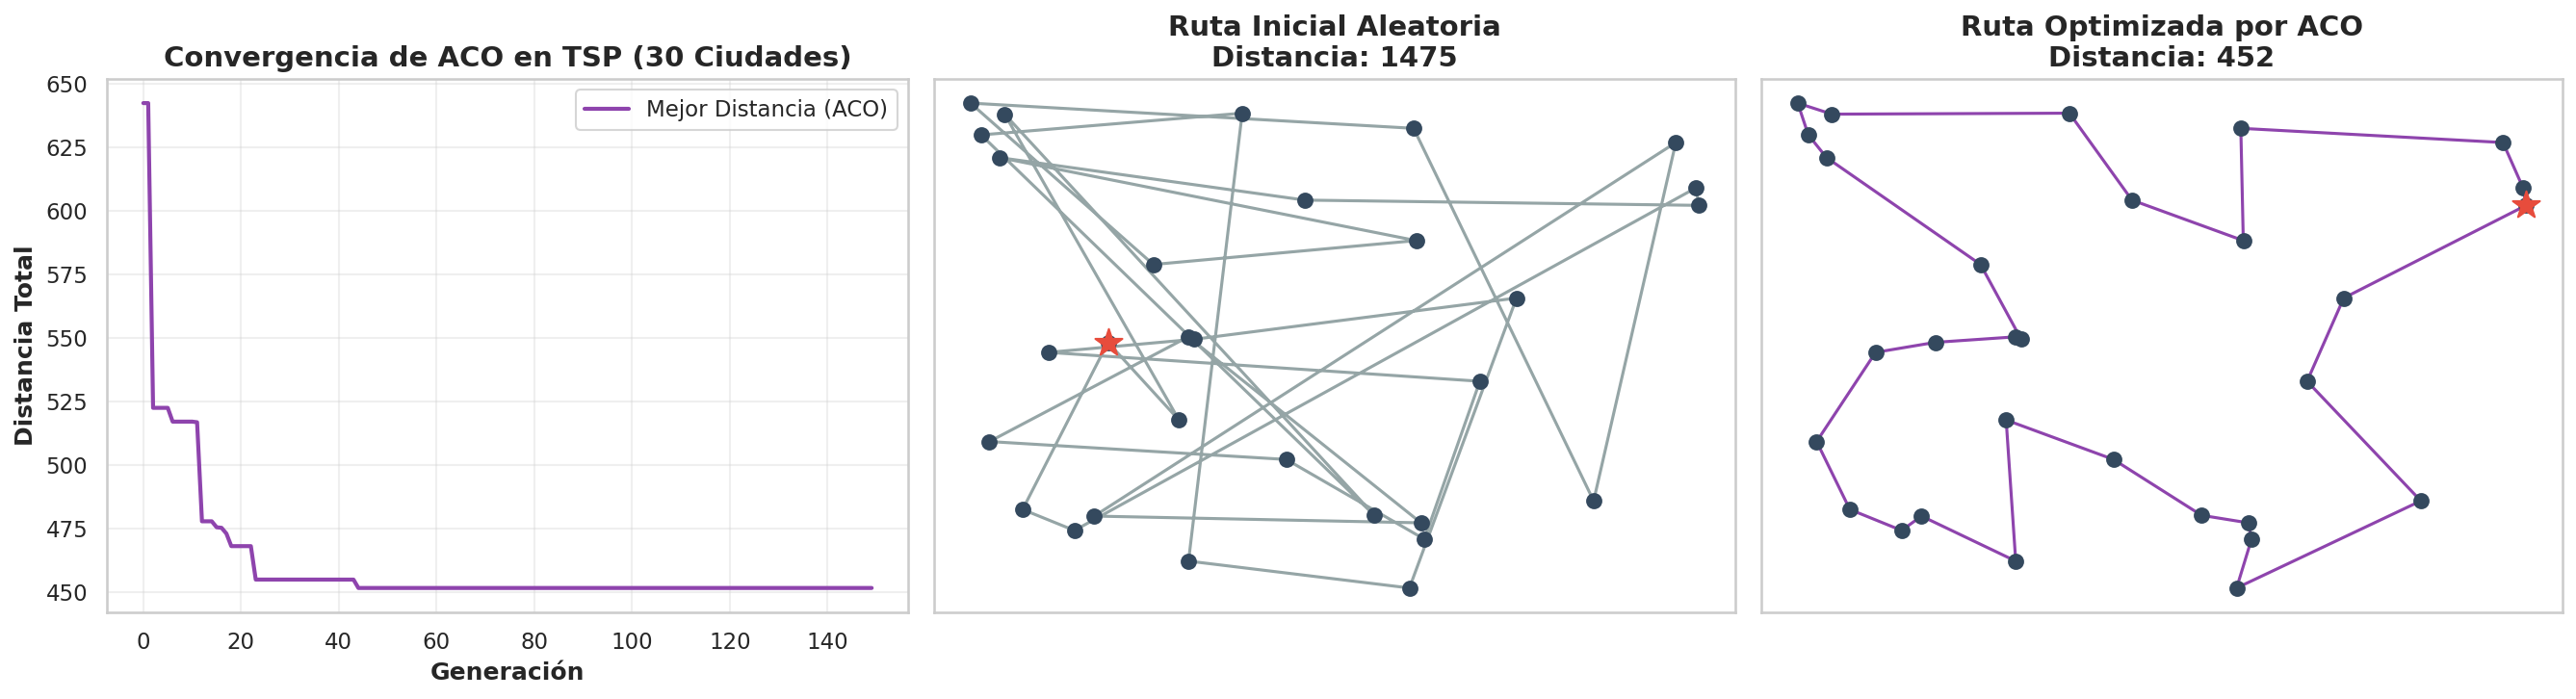

In [8]:
fig = plt.figure(figsize=(18, 5))

# 1. Curva de Convergencia
ax1 = fig.add_subplot(131)
ax1.plot(hist_aco, label='Mejor Distancia (ACO)', color='#8e44ad', lw=2)
ax1.set_title("Convergencia de ACO en TSP (30 Ciudades)")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Distancia Total")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Función auxiliar para dibujar rutas
def dibujar_ruta(ax, ruta, titulo, color_linea):
    coords_ruta = ciudades[ruta]
    coords_ruta = np.vstack((coords_ruta, coords_ruta[0])) # Cerrar el ciclo

    ax.plot(coords_ruta[:, 0], coords_ruta[:, 1], color=color_linea, lw=1.5, zorder=1)
    ax.scatter(ciudades[:, 0], ciudades[:, 1], color='#34495e', s=50, zorder=2)
    ax.scatter(coords_ruta[0, 0], coords_ruta[0, 1], color='#e74c3c', marker='*', s=200, zorder=3, label='Inicio')

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# 2. Ruta Inicial Aleatoria (Para contexto)
ruta_aleatoria = list(range(N_CIUDADES))
random.shuffle(ruta_aleatoria)
ax2 = fig.add_subplot(132)
dibujar_ruta(ax2, ruta_aleatoria, f"Ruta Inicial Aleatoria\nDistancia: {evaluar_ruta(ruta_aleatoria):.0f}", '#95a5a6')

# 3. Ruta Optimizada por ACO
ax3 = fig.add_subplot(133)
dibujar_ruta(ax3, ruta_aco, f"Ruta Optimizada por ACO\nDistancia: {dist_aco:.0f}", '#8e44ad')

plt.tight_layout()
plt.show()

### Discusión de Ingeniería: ¿Por qué ACO brilla en Grafos?



Si se compara esta ruta con la del GA del notebook de optimización combinatorio discreta, se puede notar que hay muy pocas diferencias. ACO suele encontrar soluciones más limpias (sin cruces) y en menos generaciones. ¿Por qué?

*   **El GA es "Miope" a nivel de aristas:** El cruce OX del GA toma un bloque de ciudades (ej. `[A, B, C]`) y lo pega en el hijo. El GA no sabe si la distancia entre `A` y `B` es buena o mala; solo sabe que la ruta *completa* tuvo un buen fitness.
*   **ACO evalúa la micro-estructura:** Las hormigas evalúan la calidad de **cada arista individual** ($\eta_{ij}$). La matriz de feromonas construye una memoria colectiva sobre *qué tramos específicos* son buenos.

**El Trade-off (desventaja de ACO):**  
ACO requiere mantener y actualizar una matriz de feromonas de tamaño $N \times N$. Para 30 ciudades, es una matriz de $900$ elementos (trivial). Para un problema logístico real de $100.000$ entregas, la matriz tendría $10.000.000.000$ de elementos. ACO se queda sin memoria RAM rápidamente, mientras que el GA escala mucho mejor en memoria porque solo guarda vectores 1D. De ahí la importancia de entender todo, el GA que hicimos llega casi a una solución igual de buena a la de ACO.


## El Zoológico de la Inteligencia de Enjambres

PSO y ACO son los pioneros y los más utilizados en la industria, pero en las últimas dos décadas ha habido una explosión de algoritmos inspirados en la naturaleza. Está bueno conocerlos, pero también hay que ser críticos: muchos de ellos son simplemente PSO con otro nombre y una metáfora biológica distinta.

Adjunto algunos ejemplos de otras metaheurísticas populares:

| Algoritmo | Inspiración | Caso de Uso Principal | Diferencia Clave |
| :--- | :--- | :--- | :--- |
| **Artificial Bee Colony (ABC)** | Abejas recolectoras. | Optimización Continua / Discreta. | Divide la población en abejas empleadas (explotación), observadoras (selección) y exploradoras (evitan estancamiento). Muy robusto. |
| **Firefly Algorithm (FA)** | Luciérnagas atrayéndose por luz. | Optimización Multimodal. | La atracción disminuye con la distancia. Excelente para encontrar múltiples óptimos locales simultáneamente. |
| **Grey Wolf Optimizer (GWO)** | Jerarquía de caza de los lobos. | Optimización Continua. | No hay un solo líder (`gbest`), sino tres líderes ($\alpha, \beta, \delta$) que guían a la manada. Reduce la convergencia prematura de PSO. |

> ⚠️**Criterio Profesional:** Antes de implementar un algoritmo exótico como *Salp Swarm Algorithm* o *Whale Optimization* (*sí, hay muchísimos más...*), conviene estar seguros de haber agotado las capacidades de **DE** (Evolución Diferencial) o **CMA-ES**. En la mayoría de los problemas industriales reales, los algoritmos clásicos bien calibrados superan a las metáforas biológicas complejas.

## Conexiones y Próximos Pasos



Hasta ahora, todos nuestros algoritmos optimizaron **parámetros** (números o secuencias). Pero, ¿qué pasaría si quisiéramos evolucionar la **estructura** misma de una ecuación matemática o un programa informático?

En el próximo notebook, damos un salto más abstracto: dejamos de evolucionar listas de números y comenzamos a evolucionar **Árboles de Decisión y Fórmulas Matemáticas**.

- ➡️ **Siguiente:** [Programación Genética (GP): Evolucionando Estructuras y Ecuaciones](07_programacion_genetica_gp.ipynb)
- 🔄 **Relacionado:** [Estrategias Evolutivas (ES) y Evolución Diferencial (DE)](05_estrategias_evolutivas_y_de.ipynb)


## Referencias


### Artículos Fundacionales

1. **Kennedy, J., & Eberhart, R. (1995)**. *Particle Swarm Optimization*. Proceedings of ICNN'95 - International Conference on Neural Networks.  
   (**Paper original de PSO**).

2. **Dorigo, M., Maniezzo, V., & Colorni, A. (1996)**. *Ant System: Optimization by a Colony of Cooperating Agents*. IEEE Transactions on Systems, Man, and Cybernetics.  
   (**Paper original de ACO** — base de toda la inteligencia de enjambres en grafos).

3. **Dorigo, M., & Stützle, T. (2004)**. *Ant Colony Optimization*. MIT Press.  
   (Libro de referencia para ACO).

### Recursos Prácticos
- **PySwarms** — Biblioteca especializada en PSO y otros algoritmos de enjambres. [Docs](https://pyswarms.readthedocs.io/en/latest/)
- **scikit-opt** — Biblioteca especializada en AG, DE, PSO, ACO y otros algoritmos de enjambres. [Docs](https://scikit-opt.github.io/scikit-opt/#/en/)

*NOTA: ambas están un tanto "abandonadas" en cuanto a mantenimiento...*


---


## Entorno de Ejecución


In [9]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
